Dataset Shape: (10000, 17)
Rows: 10000
Columns: 17
Index(['Order_ID', 'Product_ID', 'User_ID', 'Order_Date', 'Return_Date',
       'Product_Category', 'Product_Price', 'Order_Quantity', 'Return_Reason',
       'Return_Status', 'Days_to_Return', 'User_Age', 'User_Gender',
       'User_Location', 'Payment_Method', 'Shipping_Method',
       'Discount_Applied'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          10000 non-null  object 
 1   Product_ID        10000 non-null  object 
 2   User_ID           10000 non-null  object 
 3   Order_Date        10000 non-null  object 
 4   Return_Date       5052 non-null   object 
 5   Product_Category  10000 non-null  object 
 6   Product_Price     10000 non-null  float64
 7   Order_Quantity    10000 non-null  int64  
 8   Return_Reason     5052 non-null   

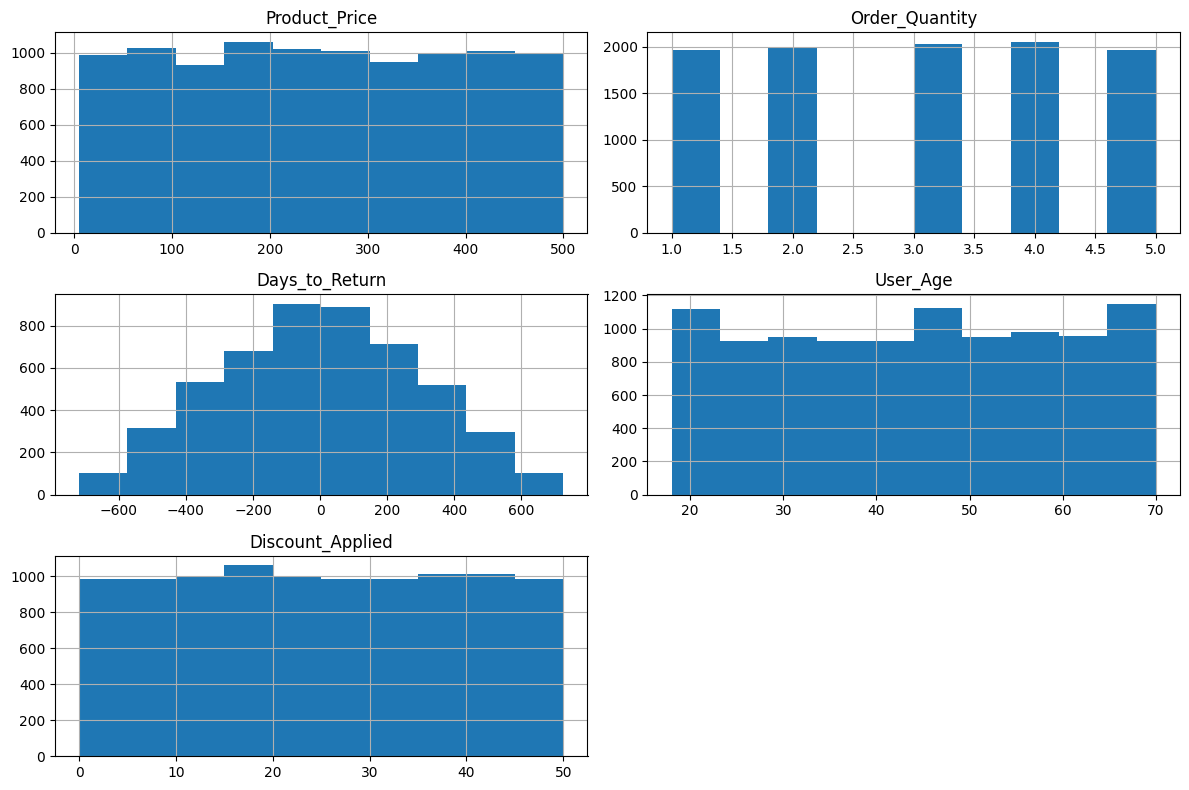

Average Days To Return: 1.45
Average Product Price: 252.37
Average Customer Age: 44.2
Product_Category
Clothing       52.450000
Electronics    50.931990
Books          50.661440
Toys           49.537037
Home           49.014778
Name: returned, dtype: float64


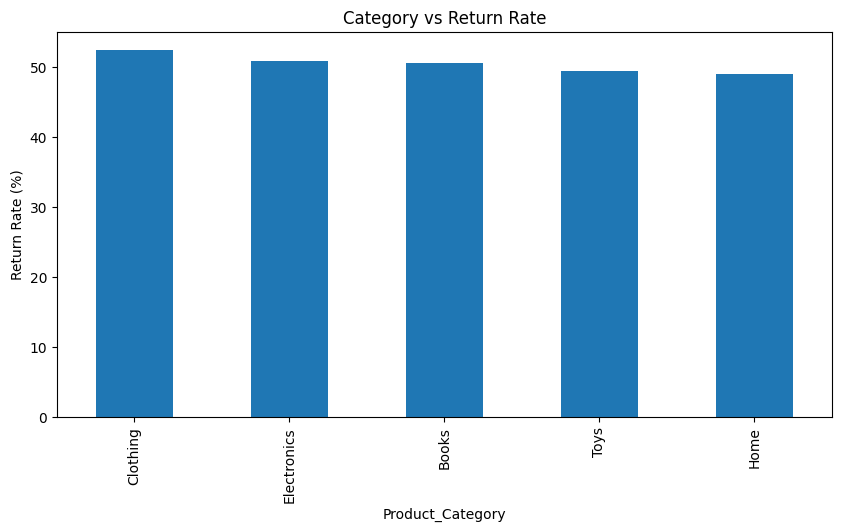

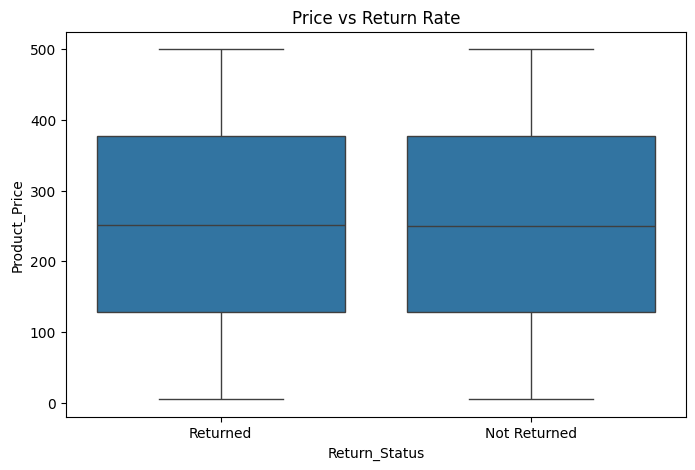

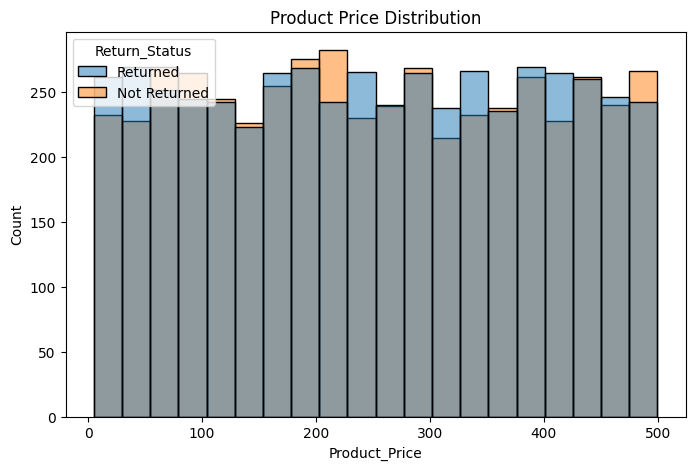

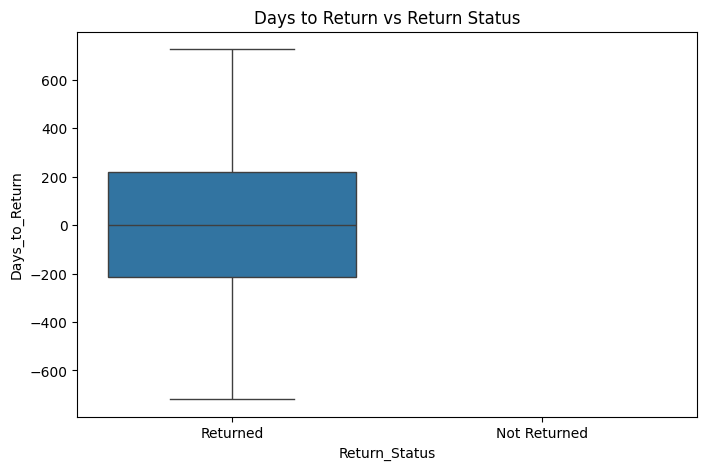

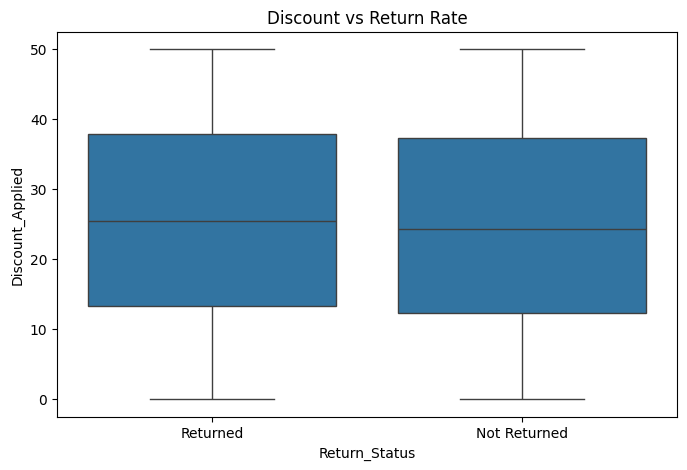

Return_Status
Not Returned    24.624919
Returned        25.351845
Name: Discount_Applied, dtype: float64


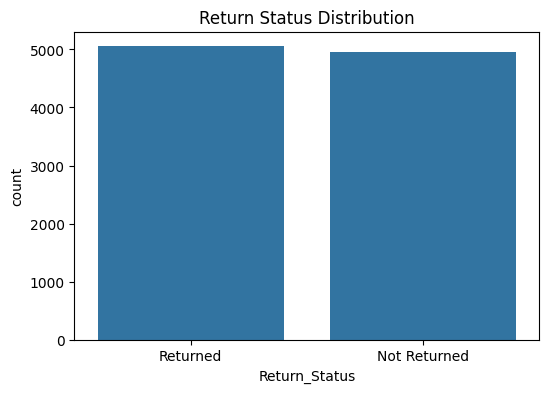

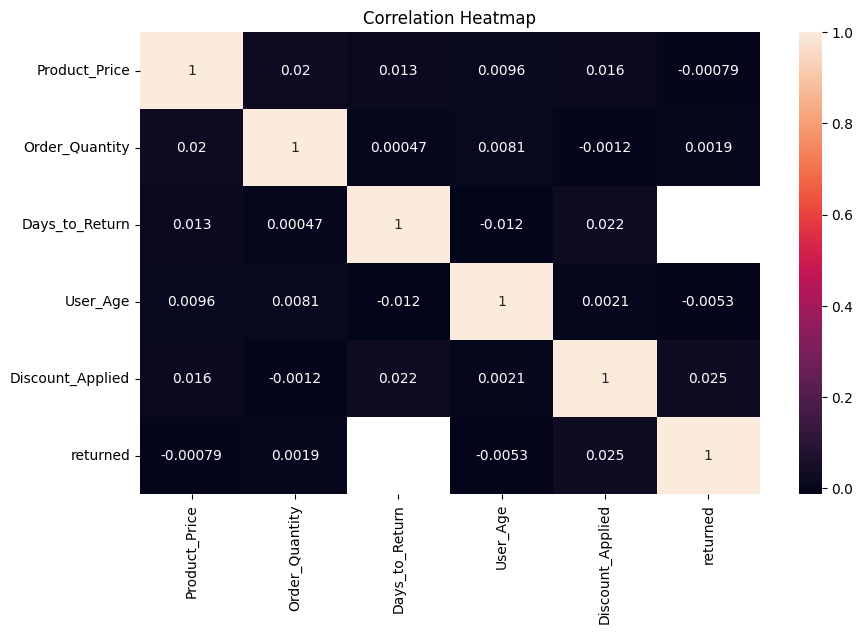

Product_Category
Clothing       52.450000
Electronics    50.931990
Books          50.661440
Toys           49.537037
Home           49.014778
Name: returned, dtype: float64
Return_Status
Not Returned    24.624919
Returned        25.351845
Name: Discount_Applied, dtype: float64


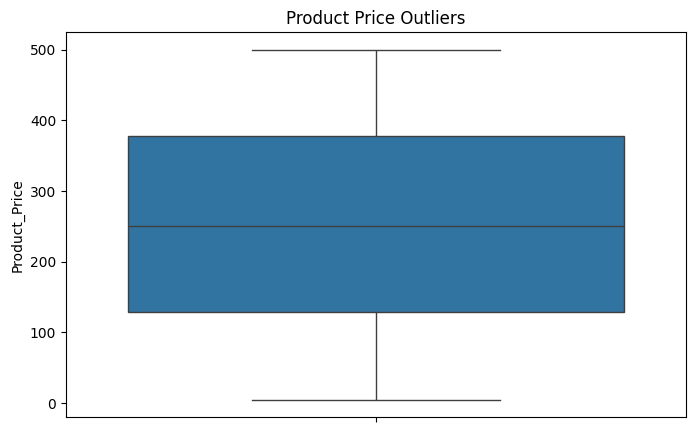

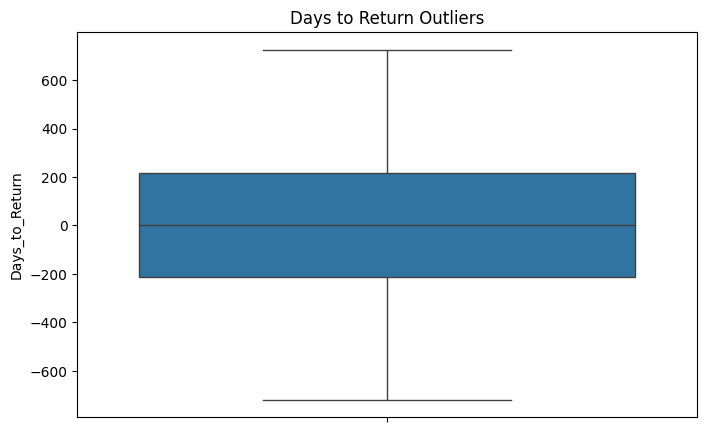

Number of Product Price Outliers:
0
Number of Delayed Return Outliers:
0
Price Z-Score Outliers:
0
Days-to-Return Z-Score Outliers:
0


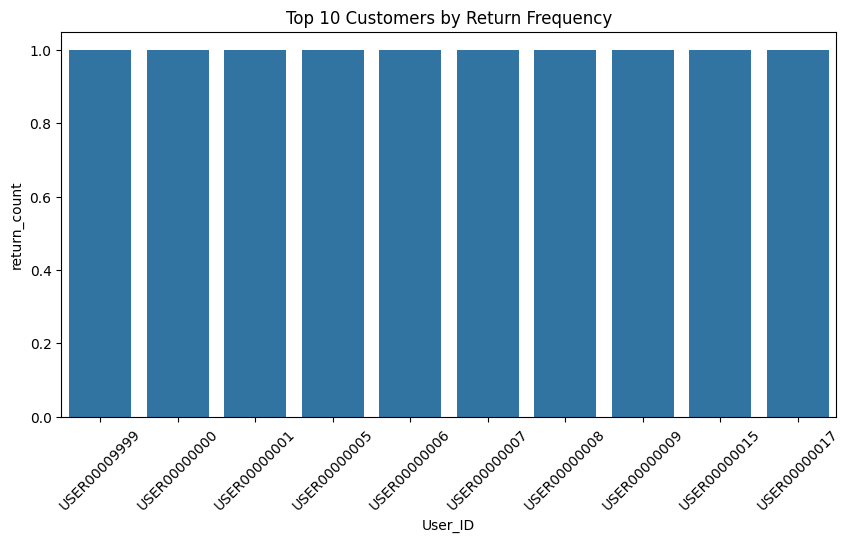

Chi-Square Statistic: 5.722713373320355
P-Value: 0.22083530275193664
Fail to Reject H₀
No significant relationship found.


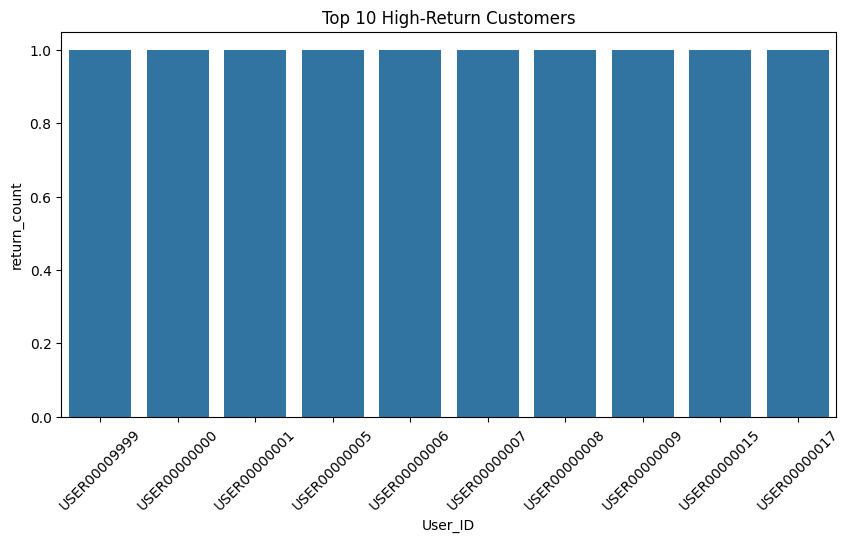

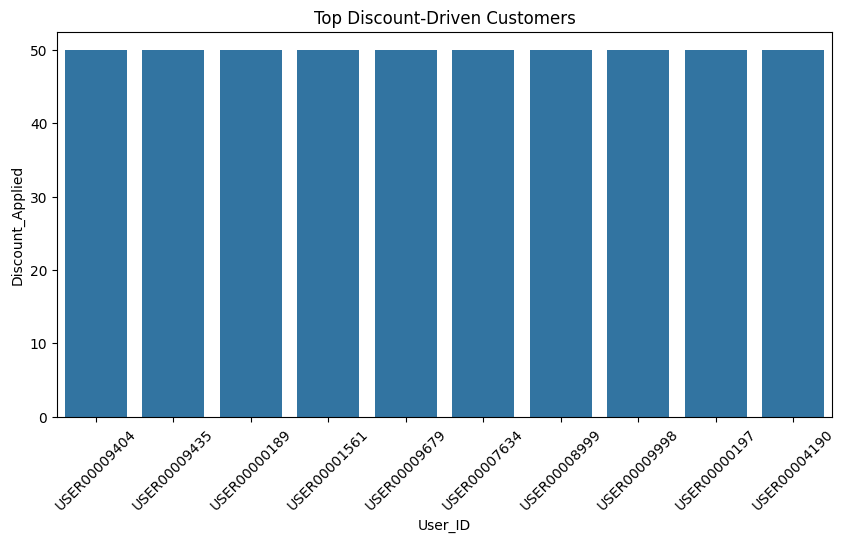

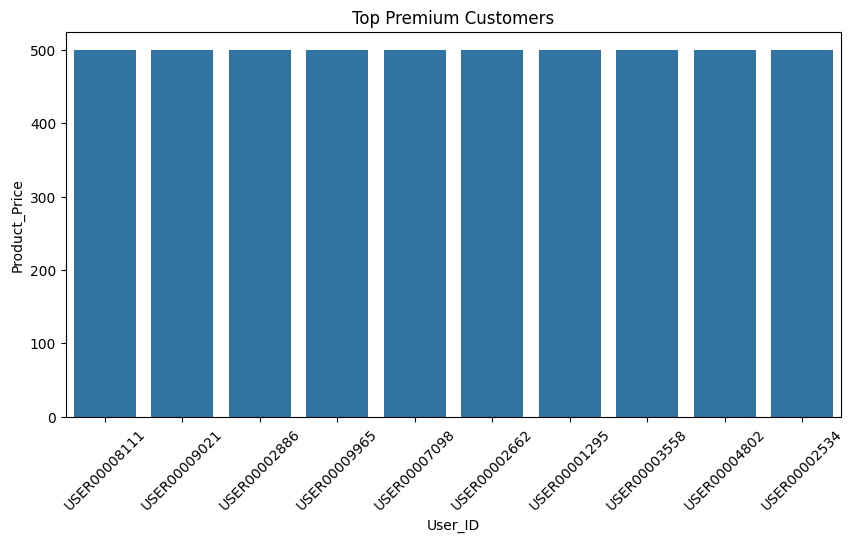

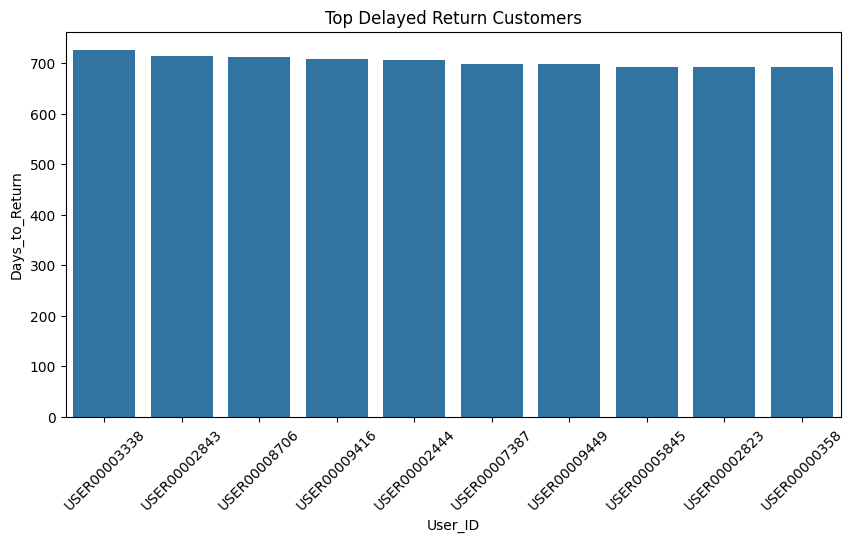

,Days_to_Return
Return_Status,
Not Returned,NaN
Returned,1.453682


In [15]:
import pandas as pd
import numpy as np
df = pd.read_csv('extracted_data/ecommerce_returns_synthetic_data.csv')
df.head()
print("Dataset Shape:", df.shape)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print(df.columns)
df.info()
df.describe()
print(df.isnull().sum())
print("Total Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())
df = df.drop_duplicates()
print("Dataset Shape After Removing Duplicates:", df.shape)
total_orders = len(df)
print("Total Orders:", total_orders)
returned_products = len(df[df['Return_Status'] == 'Returned'])
print("Total Returned Products:", returned_products)
return_percentage = (returned_products / total_orders) * 100
print("Return Percentage: {:.2f}%".format(return_percentage))
import numpy as np
numeric_df = df.select_dtypes(include=np.number)
numeric_df.describe()
print("Mean Product Price:", df['Product_Price'].mean())
print("Mean Order Quantity:", df['Order_Quantity'].mean())
print("Mean Days To Return:", df['Days_to_Return'].mean())
print("Mean User Age:", df['User_Age'].mean())
print("Mean Discount Applied:", df['Discount_Applied'].mean())
print("Median Product Price:", df['Product_Price'].median())
print("Median Order Quantity:", df['Order_Quantity'].median())
print("Median Days To Return:", df['Days_to_Return'].median())
print("Median User Age:", df['User_Age'].median())
print("Median Discount Applied:", df['Discount_Applied'].median())
print("Std Product Price:", df['Product_Price'].std())
print("Std Order Quantity:", df['Order_Quantity'].std())
print("Std Days To Return:", df['Days_to_Return'].std())
print("Std User Age:", df['User_Age'].std())
print("Std Discount Applied:", df['Discount_Applied'].std())
print(df[['Product_Price',
          'Order_Quantity',
          'Days_to_Return',
          'User_Age',
          'Discount_Applied']].quantile([0.25,0.50,0.75]))
import matplotlib.pyplot as plt

df[['Product_Price',
    'Order_Quantity',
    'Days_to_Return',
    'User_Age',
    'Discount_Applied']].hist(figsize=(12,8))

plt.tight_layout()
plt.show()
print("Average Days To Return:",
      round(df['Days_to_Return'].mean(),2))
print("Average Product Price:",
      round(df['Product_Price'].mean(),2))
print("Average Customer Age:",
      round(df['User_Age'].mean(),2))
df['returned'] = df['Return_Status'].apply(
    lambda x: 1 if x == 'Returned' else 0
)
category_return_rate = df.groupby('Product_Category')['returned'].mean()*100
print(category_return_rate.sort_values(ascending=False))
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,5))
category_return_rate.sort_values(ascending=False).plot(kind='bar')
plt.title('Category vs Return Rate')
plt.ylabel('Return Rate (%)')
plt.show()
plt.figure(figsize=(8,5))
sns.boxplot(
    x='Return_Status',
    y='Product_Price',
    data=df
)
plt.title('Price vs Return Rate')
plt.show()
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='Product_Price',
    hue='Return_Status',
    bins=20
)
plt.title('Product Price Distribution')
plt.show()
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Return_Status',
    y='Days_to_Return',
    data=df
)
plt.title('Days to Return vs Return Status')
plt.show()
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Return_Status',
    y='Discount_Applied',
    data=df
)
plt.title('Discount vs Return Rate')
plt.show()
print(df.groupby('Return_Status')['Discount_Applied'].mean())
plt.figure(figsize=(6,4))

sns.countplot(
    x='Return_Status',
    data=df
)
plt.title('Return Status Distribution')
plt.show()
numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True
)
plt.title('Correlation Heatmap')
plt.show()
category_return_rate = df.groupby('Product_Category')['returned'].mean()*100
print(category_return_rate.sort_values(ascending=False))
discount_compare = df.groupby('Return_Status')['Discount_Applied'].mean()
print(discount_compare)
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))
sns.boxplot(y=df['Product_Price'])
plt.title("Product Price Outliers")
plt.show()
plt.figure(figsize=(8,5))
sns.boxplot(y=df['Days_to_Return'])
plt.title("Days to Return Outliers")
plt.show()
Q1 = df['Product_Price'].quantile(0.25)
Q3 = df['Product_Price'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

price_outliers = df[
    (df['Product_Price'] < lower_bound) |
    (df['Product_Price'] > upper_bound)
]
print("Number of Product Price Outliers:")
print(price_outliers.shape[0])
price_outliers.head()
Q1 = df['Days_to_Return'].quantile(0.25)
Q3 = df['Days_to_Return'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

delay_outliers = df[
    (df['Days_to_Return'] < lower_bound) |
    (df['Days_to_Return'] > upper_bound)
]
print("Number of Delayed Return Outliers:")
print(delay_outliers.shape[0])
delay_outliers.head()
from scipy.stats import zscore

df['price_zscore'] = zscore(df['Product_Price'])

price_z_outliers = df[
    abs(df['price_zscore']) > 3
]
print("Price Z-Score Outliers:")
print(price_z_outliers.shape[0])
price_z_outliers.head()
df['days_zscore'] = zscore(df['Days_to_Return'])

delay_z_outliers = df[
    abs(df['days_zscore']) > 3
]
print("Days-to-Return Z-Score Outliers:")
print(delay_z_outliers.shape[0])
delay_z_outliers.head()
customer_returns = df[df['Return_Status'] == 'Returned'] \
                    .groupby('User_ID') \
                    .size() \
                    .reset_index(name='return_count')

customer_returns.sort_values(
    by='return_count',
    ascending=False
).head(10)
top_customers = customer_returns.sort_values(
    by='return_count',
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x='User_ID',
    y='return_count',
    data=top_customers
)
plt.title("Top 10 Customers by Return Frequency")
plt.xticks(rotation=45)
plt.show()
high_price_returns = df[
    (df['Return_Status'] == 'Returned')
]

high_price_returns = high_price_returns.sort_values(
    by='Product_Price',
    ascending=False
)

high_price_returns[
    ['Product_ID',
     'Product_Category',
     'Product_Price']
].head(10)
df.sort_values(
    by='Days_to_Return',
    ascending=False
)[
    ['Order_ID',
     'Product_Category',
     'Days_to_Return']
].head(10)
from scipy.stats import chi2_contingency
contingency_table = pd.crosstab(
    df['Product_Category'],
    df['Return_Status']
)

contingency_table
chi2, p, dof, expected = chi2_contingency(
    contingency_table
)

print("Chi-Square Statistic:", chi2)
print("P-Value:", p)
if p < 0.05:
    print("Reject H₀")
    print("Product Category significantly affects return behavior.")
else:
    print("Fail to Reject H₀")
    print("No significant relationship found.")
high_return_customers = df[df['Return_Status']=='Returned'] \
    .groupby('User_ID') \
    .size() \
    .reset_index(name='return_count')
high_return_customers = high_return_customers.sort_values(
    by='return_count',
    ascending=False
)
high_return_customers.head(10)
import matplotlib.pyplot as plt
import seaborn as sns
top10 = high_return_customers.head(10)
plt.figure(figsize=(10,5))
sns.barplot(
    x='User_ID',
    y='return_count',
    data=top10
)
plt.title("Top 10 High-Return Customers")
plt.xticks(rotation=45)
plt.show()
discount_customers = df.groupby('User_ID')[
    'Discount_Applied'
].mean().reset_index()

discount_customers = discount_customers.sort_values(
    by='Discount_Applied',
    ascending=False
)
discount_customers.head(10)
top_discount = discount_customers.head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x='User_ID',
    y='Discount_Applied',
    data=top_discount
)

plt.title("Top Discount-Driven Customers")

plt.xticks(rotation=45)

plt.show()
premium_customers = df.groupby('User_ID')[
    'Product_Price'
].sum().reset_index()

premium_customers = premium_customers.sort_values(
    by='Product_Price',
    ascending=False
)

premium_customers.head(10)
top_premium = premium_customers.head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x='User_ID',
    y='Product_Price',
    data=top_premium
)

plt.title("Top Premium Customers")

plt.xticks(rotation=45)

plt.show()
delayed_customers = df.groupby('User_ID')[
    'Days_to_Return'
].mean().reset_index()

delayed_customers = delayed_customers.sort_values(
    by='Days_to_Return',
    ascending=False
)

delayed_customers.head(10)
top_delayed = delayed_customers.head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x='User_ID',
    y='Days_to_Return',
    data=top_delayed
)

plt.title("Top Delayed Return Customers")

plt.xticks(rotation=45)

plt.show()
segment_summary = pd.DataFrame({
    'High_Return_Customers':
    [high_return_customers.shape[0]],

    'Discount_Driven_Customers':
    [discount_customers.shape[0]],

    'Premium_Customers':
    [premium_customers.shape[0]],

    'Delayed_Customers':
    [delayed_customers.shape[0]]
})

segment_summary
df.groupby('Return_Status')[
    'Product_Price'
].mean()
df.groupby('Return_Status')[
    'Discount_Applied'
].mean()
df.groupby('Return_Status')[
    'Days_to_Return'
].mean()





In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!ls "/content/drive/MyDrive"


'12th marksheet.pdf.pdf'
'(422523104005)ass 2- excel 1 (1).gsheet'
'(422523104005)ass 2- excel 1 (2).gsheet'
'(422523104005)ass 2- excel 1.gsheet'
'(422523104005) EXCEL ASSIGNMENT 2.xlsx'
'(422523104005) EXCEL ASSIGNMENT 3.pdf'
 aadhar.pdf
'Activity tdy.pdf'
'archive (2).zip'
 Classroom
'Colab Notebooks'
'Dataset for testing (10).gsheet'
'Dataset for testing (11).gsheet'
'Dataset for testing (12).gsheet'
'Dataset for testing (13).gsheet'
'Dataset for testing (1).gsheet'
'Dataset for testing (2).gsheet'
'Dataset for testing (3).gsheet'
'Dataset for testing (4).gsheet'
'Dataset for testing (5).gsheet'
'Dataset for testing (6).gsheet'
'Dataset for testing (7).gsheet'
'Dataset for testing (8).gsheet'
'Dataset for testing (9).gsheet'
'Dataset for testing.gsheet'
'Document from 𝕣ꫀꪀꪊ 💜 (1).pdf'
'Document from 𝕣ꫀꪀꪊ 💜.pdf'
 EAadhaar_0632140915542720201119122542_1903202414734.pdf
 eCertificate.pdf
'Excel '
'Excel assignment 1.gsheet'
 IMG_20250508_161609.jpg
 Job
'matplotlib(K.ILAKKIYA).pdf'
'Na

In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/ecommerce_returns_synthetic_data.csv')
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/ecommerce_returns_synthetic_data.csv'

In [ ]:
import zipfile

zip_path = '/content/drive/MyDrive/archive (2).zip'
extract_path = '/content/extracted_data'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Files extracted successfully!")

Files extracted successfully!


In [ ]:
import os

for root, dirs, files in os.walk('/content/extracted_data'):
    for file in files:
        print(os.path.join(root, file))

/content/extracted_data/ecommerce_returns_synthetic_data.csv


In [ ]:
import pandas as pd
df = pd.read_csv('/content/extracted_data/ecommerce_returns_synthetic_data.csv')
df.head()

,Order_ID,Product_ID,User_ID,Order_Date,Return_Date,Product_Category,Product_Price,Order_Quantity,Return_Reason,Return_Status,Days_to_Return,User_Age,User_Gender,User_Location,Payment_Method,Shipping_Method,Discount_Applied
0,ORD00000000,PROD00000000,USER00000000,2023-08-05,2024-08-26,Clothing,411.59,3,Changed mind,Returned,387.0,58,Male,City54,Debit Card,Next-Day,45.27
1,ORD00000001,PROD00000001,USER00000001,2023-10-09,2023-11-09,Books,288.88,3,Wrong item,Returned,31.0,68,Female,City85,Credit Card,Express,47.79
2,ORD00000002,PROD00000002,USER00000002,2023-05-06,NaN,Toys,390.03,5,NaN,Not Returned,NaN,22,Female,City30,Debit Card,Next-Day,26.64
3,ORD00000003,PROD00000003,USER00000003,2024-08-29,NaN,Toys,401.09,3,NaN,Not Returned,NaN,40,Male,City95,PayPal,Next-Day,15.37
4,ORD00000004,PROD00000004,USER00000004,2023-01-16,NaN,Books,110.09,4,NaN,Not Returned,NaN,34,Female,City80,Gift Card,Standard,16.37
